# 03 - Indicadores por Comuna de Ingresos Operacionales
**Proyecto:** Indice de Ingresos Operacionales - Cali  
**Equipo:** ITT Cali Inteligente - Gobierno de Datos  
**Repositorio:** https://github.com/j0rg3c45/Indice_ingresos_operacionales.git

## Objetivo
Calcular indicadores economicos por comuna cruzando el Registro Mercantil 2025
con datos demograficos (Personas por Hogar 2016) y el GeoJSON de comunas.

## 1. Instalacion de dependencias

In [12]:
# Descomentar en Colab
# !pip install pandas openpyxl geopandas folium matplotlib seaborn mapclassify

## 2. Deteccion de entorno y rutas

In [13]:
import os
from pathlib import Path
import zipfile, tempfile

REPO_URL = "https://github.com/j0rg3c45/Indice_ingresos_operacionales.git"
REPO_NAME = "Indice_ingresos_operacionales"
EN_COLAB = os.path.exists("/content")

if EN_COLAB:
    WORK_DIR = Path("/content") / REPO_NAME
    if not WORK_DIR.exists():
        os.system(f"git clone {REPO_URL}")
    else:
        os.system(f"cd {WORK_DIR} && git pull")
else:
    WORK_DIR = Path(os.getcwd()).parent
    if not (WORK_DIR / "README.md").exists():
        WORK_DIR = Path(os.getcwd())

DATA_DIR = WORK_DIR / "data"
GEO_DIR = DATA_DIR / "info_geo"
OUTPUT_DIR = WORK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entorno: {'Colab' if EN_COLAB else 'Local'}")
print(f"Datos: {DATA_DIR}")

Entorno: Colab
Datos: /content/Indice_ingresos_operacionales/data


## 3. Carga de datos

In [14]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Funcion de formato abreviado ---
def formato_abreviado(x, pos):
    '''Convierte numeros grandes: 1000->1K, 1000000->1M, 1000000000->1B'''
    if abs(x) >= 1e9: return f"{x/1e9:.1f}B"
    elif abs(x) >= 1e6: return f"{x/1e6:.1f}M"
    elif abs(x) >= 1e3: return f"{x/1e3:.0f}K"
    else: return f"{x:.0f}"

def aplicar_formato(ax, eje="y"):
    fmt = mticker.FuncFormatter(formato_abreviado)
    if eje == "y": ax.yaxis.set_major_formatter(fmt)
    elif eje == "x": ax.xaxis.set_major_formatter(fmt)

# 3.1 Registro Mercantil
print("[1/3] Cargando Registro Mercantil...")
ARCHIVO_EXCEL = list(DATA_DIR.glob("*.xlsx"))[0]
df = pd.read_excel(ARCHIVO_EXCEL, engine="openpyxl")
df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
print(f"  Registros: {len(df):,}")

# 3.2 GeoJSON de comunas
print("[2/3] Cargando GeoJSON comunas...")
geojson_files = list(GEO_DIR.glob("**/Comunas.geojson"))
gdf_comunas = gpd.read_file(geojson_files[0]) if geojson_files else None
if gdf_comunas is not None:
    if gdf_comunas.crs and gdf_comunas.crs.to_epsg() != 4326:
        gdf_comunas = gdf_comunas.to_crs("EPSG:4326")
    print(f"  Comunas: {len(gdf_comunas)}")

# 3.3 Shapefile demografico
print("[3/3] Cargando datos demograficos...")
zip_demo = [f for f in GEO_DIR.glob("*.zip") if "Personas" in f.name]
gdf_demo = None
if zip_demo:
    with tempfile.TemporaryDirectory() as tmp:
        with zipfile.ZipFile(zip_demo[0], "r") as z:
            z.extractall(tmp)
        shp = list(Path(tmp).glob("**/*.shp"))
        if shp:
            gdf_demo = gpd.read_file(shp[0])
            if gdf_demo.crs and gdf_demo.crs.to_epsg() != 4326:
                gdf_demo = gdf_demo.to_crs("EPSG:4326")
            print(f"  Barrios demograficos: {len(gdf_demo)}")

[1/3] Cargando Registro Mercantil...
  Registros: 122,535
[2/3] Cargando GeoJSON comunas...
  Comunas: 22
[3/3] Cargando datos demograficos...
  Barrios demograficos: 334


## 4. Preparacion de indicadores por comuna

In [15]:
# Identificar columnas
col_comuna = [c for c in df.columns if 'comuna' in c][0]
col_ingresos = [c for c in df.columns if 'ingreso' in c][0]
col_empleo = [c for c in df.columns if 'personal' in c][0]
col_tamano = [c for c in df.columns if 'tama' in c][0]
col_ciiu = [c for c in df.columns if 'codigo' in c and 'ciiu' in c][0]

df[col_ingresos] = pd.to_numeric(df[col_ingresos], errors='coerce')
df[col_empleo] = pd.to_numeric(df[col_empleo], errors='coerce')
df_cc = df[df[col_comuna].notna()].copy()

# --- Indicadores base por comuna ---
ind = df_cc.groupby(col_comuna).agg(
    total_empresas=(col_comuna, 'size'),
    ingresos_promedio=(col_ingresos, 'mean'),
    ingresos_mediana=(col_ingresos, 'median'),
    ingresos_total=(col_ingresos, 'sum'),
    empleo_total=(col_empleo, 'sum'),
    empleo_promedio=(col_empleo, 'mean'),
).reset_index()

# Tasa de microempresas
micro = df_cc[df_cc[col_tamano].str.contains('MICRO', case=False, na=False)]
tasa_micro = micro.groupby(col_comuna).size().reset_index(name='n_micro')
ind = ind.merge(tasa_micro, on=col_comuna, how='left')
# Formula: (microempresas / total_empresas) * 100
# Mide que porcentaje del tejido empresarial son microempresas
ind['pct_micro'] = (ind['n_micro'] / ind['total_empresas'] * 100).round(1)

# Diversidad economica
diversidad = df_cc.groupby(col_comuna)[col_ciiu].nunique().reset_index(name='n_ciiu')
ind = ind.merge(diversidad, on=col_comuna, how='left')

# Empresas con ingresos > 0
con_ingresos = df_cc[df_cc[col_ingresos] > 0].groupby(col_comuna).size().reset_index(name='empresas_con_ingresos')
ind = ind.merge(con_ingresos, on=col_comuna, how='left')
# Formula: (empresas_con_ingresos / total_empresas) * 100
# Mide que porcentaje de empresas reportan actividad economica real
ind['pct_con_ingresos'] = (ind['empresas_con_ingresos'] / ind['total_empresas'] * 100).round(1)

# Ingresos promedio solo de empresas activas (con ingresos > 0)
ing_activas = df_cc[df_cc[col_ingresos] > 0].groupby(col_comuna)[col_ingresos].mean().reset_index(name='ingresos_prom_activas')
ind = ind.merge(ing_activas, on=col_comuna, how='left')

print(f"Indicadores calculados para {len(ind)} comunas")
ind.sort_values('total_empresas', ascending=False).head(10)

Indicadores calculados para 39 comunas


,comuna,total_empresas,ingresos_promedio,ingresos_mediana,ingresos_total,empleo_total,empleo_promedio,n_micro,pct_micro,n_ciiu,empresas_con_ingresos,pct_con_ingresos,ingresos_prom_activas
3,Comuna 02,13994,2.829356e+09,2335000.0,3.494537e+13,189257.0,13.547387,12538,89.6,392,6529,46.7,5.352343e+09
18,Comuna 17,13238,1.082966e+09,0.0,1.198194e+13,48715.0,3.681883,12647,95.5,381,4380,33.1,2.735603e+09
4,Comuna 03,11032,2.291956e+09,0.0,2.221823e+13,66022.0,5.987847,10353,93.8,361,4224,38.3,5.259997e+09
20,Comuna 19,10320,1.339765e+09,0.0,1.201501e+13,67758.0,6.572066,9545,92.5,369,4282,41.5,2.805967e+09
11,Comuna 10,6020,5.314957e+08,0.0,2.718600e+12,15322.0,2.547298,5830,96.8,313,1831,30.4,1.484763e+09
10,Comuna 09,5838,5.540401e+08,0.0,2.792916e+12,17728.0,3.037177,5519,94.5,310,1954,33.5,1.429333e+09
9,Comuna 08,5813,1.069646e+09,0.0,5.371761e+12,27620.0,4.753055,5463,94.0,326,1941,33.4,2.767523e+09
5,Comuna 04,4611,2.523850e+09,0.0,1.015092e+13,41082.0,8.917300,4178,90.6,327,1821,39.5,5.574367e+09
7,Comuna 06,3959,2.091863e+08,0.0,6.888504e+11,5471.0,1.382264,3918,99.0,276,879,22.2,7.836750e+08
19,Comuna 18,3603,1.689830e+08,0.0,5.133704e+11,4744.0,1.316681,3540,98.3,284,875,24.3,5.867092e+08


## 5. Cruce con datos demograficos por comuna

In [16]:
# Agregar poblacion por comuna desde el shapefile demografico
if gdf_demo is not None:
    demo_comuna = gdf_demo.groupby('comuna').agg(
        poblacion=('poblacio_3', 'sum'),
        viviendas=('viviendas', 'sum'),
        hogares=('hogares', 'sum'),
    ).reset_index()
    
    # Normalizar clave de comuna
    demo_comuna['comuna_key'] = 'Comuna ' + demo_comuna['comuna'].astype(int).astype(str).str.zfill(2)
    
    ind = ind.merge(demo_comuna[['comuna_key', 'poblacion', 'viviendas', 'hogares']],
                    left_on=col_comuna, right_on='comuna_key', how='left')
    
    # --- INDICADORES CRUZADOS ---
    
    # Empresas por 1000 habitantes
    # Formula: (total_empresas / poblacion) * 1000
    # Mide densidad empresarial relativa. Permite comparar comunas de distinto tamano.
    ind['empresas_por_1000hab'] = (ind['total_empresas'] / ind['poblacion'] * 1000).round(1)
    
    # Empleo por 1000 habitantes
    # Formula: (empleo_total / poblacion) * 1000
    # Identifica comunas que son polos de empleo vs comunas dormitorio.
    ind['empleo_por_1000hab'] = (ind['empleo_total'] / ind['poblacion'] * 1000).round(1)
    
    # Ingresos per capita
    # Formula: ingresos_total / poblacion
    # Productividad economica del territorio por habitante.
    ind['ingresos_per_capita'] = (ind['ingresos_total'] / ind['poblacion']).round(0)
    
    # Empleo por hogar
    # Formula: empleo_total / hogares
    # Si > 1: la comuna genera mas empleo del que necesita (exporta empleo)
    # Si < 1: la comuna depende de empleo externo (importa empleo)
    ind['empleo_por_hogar'] = (ind['empleo_total'] / ind['hogares']).round(2)
    
    print(f"Datos demograficos cruzados para {ind['poblacion'].notna().sum()} comunas")
    print(f"Poblacion total cubierta: {ind['poblacion'].sum():,.0f}")
else:
    print("[!] Sin datos demograficos. Solo indicadores base disponibles.")

Datos demograficos cruzados para 22 comunas
Poblacion total cubierta: 1,209,627


## 6. Tabla de indicadores por comuna

In [17]:
# Tabla formateada
ind_sorted = ind.sort_values('total_empresas', ascending=False)

print('=' * 110)
print('INDICADORES DE INGRESOS OPERACIONALES POR COMUNA - Cali 2025')
print('=' * 110)

has_demo = 'poblacion' in ind.columns and ind['poblacion'].notna().any()

if has_demo:
    print(f"{'Comuna':<12} {'Empresas':>8} {'Ing.Prom':>10} {'Ing.Activas':>12} {'%ConIng':>7} {'Empleo':>7} {'%Micro':>7} {'CIIU':>5} {'Emp/1Khab':>10} {'Ing/Cap':>9}")
    print('-' * 110)
    for _, r in ind_sorted.iterrows():
        ing_p = f"${r['ingresos_promedio']/1e6:.1f}M" if pd.notna(r['ingresos_promedio']) and r['ingresos_promedio'] >= 1e6 else "$0"
        ing_a = f"${r['ingresos_prom_activas']/1e6:.1f}M" if pd.notna(r.get('ingresos_prom_activas')) and r['ingresos_prom_activas'] >= 1e6 else "$0"
        pct_i = f"{r['pct_con_ingresos']:.0f}%" if pd.notna(r.get('pct_con_ingresos')) else "N/A"
        emp1k = f"{r['empresas_por_1000hab']:.0f}" if pd.notna(r.get('empresas_por_1000hab')) else "N/A"
        ing_c = f"${r['ingresos_per_capita']/1e6:.1f}M" if pd.notna(r.get('ingresos_per_capita')) and r.get('ingresos_per_capita',0) >= 1e6 else (f"${r['ingresos_per_capita']/1e3:.0f}K" if pd.notna(r.get('ingresos_per_capita')) else "N/A")
        print(f"{r[col_comuna]:<12} {int(r['total_empresas']):>8,} {ing_p:>10} {ing_a:>12} {pct_i:>7} {int(r['empleo_total']):>7,} {r['pct_micro']:>6.1f}% {int(r['n_ciiu']):>5} {emp1k:>10} {ing_c:>9}")
else:
    print(f"{'Comuna':<12} {'Empresas':>8} {'Ing.Prom':>10} {'Ing.Activas':>12} {'%ConIng':>7} {'Empleo':>7} {'%Micro':>7} {'CIIU':>5}")
    print('-' * 110)
    for _, r in ind_sorted.iterrows():
        ing_p = f"${r['ingresos_promedio']/1e6:.1f}M" if pd.notna(r['ingresos_promedio']) and r['ingresos_promedio'] >= 1e6 else "$0"
        ing_a = f"${r['ingresos_prom_activas']/1e6:.1f}M" if pd.notna(r.get('ingresos_prom_activas')) and r['ingresos_prom_activas'] >= 1e6 else "$0"
        pct_i = f"{r['pct_con_ingresos']:.0f}%" if pd.notna(r.get('pct_con_ingresos')) else "N/A"
        print(f"{r[col_comuna]:<12} {int(r['total_empresas']):>8,} {ing_p:>10} {ing_a:>12} {pct_i:>7} {int(r['empleo_total']):>7,} {r['pct_micro']:>6.1f}% {int(r['n_ciiu']):>5}")

print('=' * 110)

INDICADORES DE INGRESOS OPERACIONALES POR COMUNA - Cali 2025
Comuna       Empresas   Ing.Prom  Ing.Activas %ConIng  Empleo  %Micro  CIIU  Emp/1Khab   Ing/Cap
--------------------------------------------------------------------------------------------------------------
Comuna 02      13,994   $2829.4M     $5352.3M     47% 189,257   89.6%   392       1861  $4646.4M
Comuna 17      13,238   $1083.0M     $2735.6M     33%  48,715   95.5%   381       8658  $7836.5M
Comuna 03      11,032   $2292.0M     $5260.0M     38%  66,022   93.8%   361        641  $1291.7M
Comuna 19      10,320   $1339.8M     $2806.0M     42%  67,758   92.5%   369       1700  $1979.4M
Comuna 10       6,020    $531.5M     $1484.8M     30%  15,322   96.8%   313        275   $124.1M
Comuna 09       5,838    $554.0M     $1429.3M     34%  17,728   94.5%   310        295   $141.2M
Comuna 08       5,813   $1069.6M     $2767.5M     33%  27,620   94.0%   326        109   $100.8M
Comuna 04       4,611   $2523.8M     $5574.4M     40

## 7. Graficos de indicadores

[OK] Guardado: ind_panel_ingresos_comuna.png


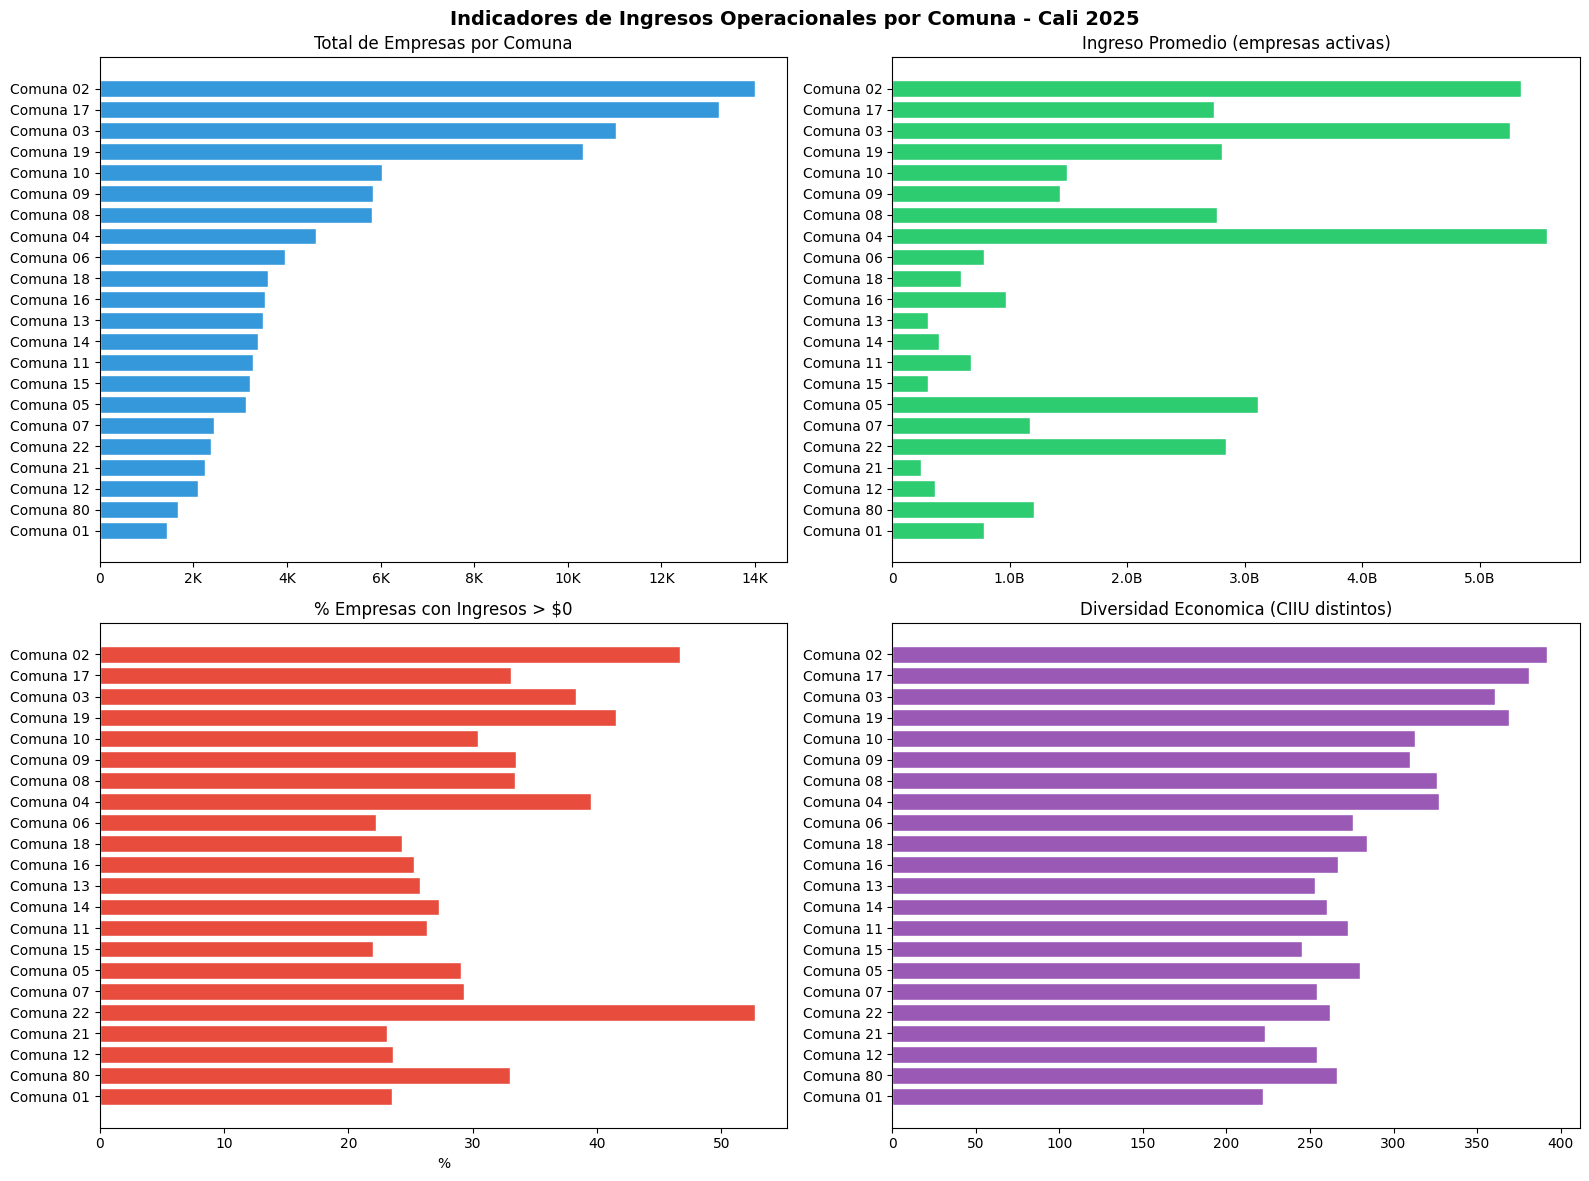

In [18]:
# 7.1 Panel de 4 graficos principales
top = ind_sorted.head(22)  # Solo comunas con GeoJSON

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Indicadores de Ingresos Operacionales por Comuna - Cali 2025', fontsize=14, fontweight='bold')

# 1. Total empresas
axes[0,0].barh(top[col_comuna], top['total_empresas'], color='#3498db', edgecolor='white')
axes[0,0].set_title('Total de Empresas por Comuna')
axes[0,0].invert_yaxis()
aplicar_formato(axes[0,0], 'x')

# 2. Ingresos promedio (solo activas)
axes[0,1].barh(top[col_comuna], top['ingresos_prom_activas'].fillna(0), color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Ingreso Promedio (empresas activas)')
axes[0,1].invert_yaxis()
aplicar_formato(axes[0,1], 'x')

# 3. % con ingresos
axes[1,0].barh(top[col_comuna], top['pct_con_ingresos'].fillna(0), color='#e74c3c', edgecolor='white')
axes[1,0].set_title('% Empresas con Ingresos > $0')
axes[1,0].set_xlabel('%')
axes[1,0].invert_yaxis()

# 4. Diversidad CIIU
axes[1,1].barh(top[col_comuna], top['n_ciiu'].fillna(0), color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Diversidad Economica (CIIU distintos)')
axes[1,1].invert_yaxis()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ind_panel_ingresos_comuna.png', dpi=150, bbox_inches='tight', facecolor='white')
print('[OK] Guardado: ind_panel_ingresos_comuna.png')
plt.show()

[OK] Guardado: ind_scatter_ingresos_activas.png


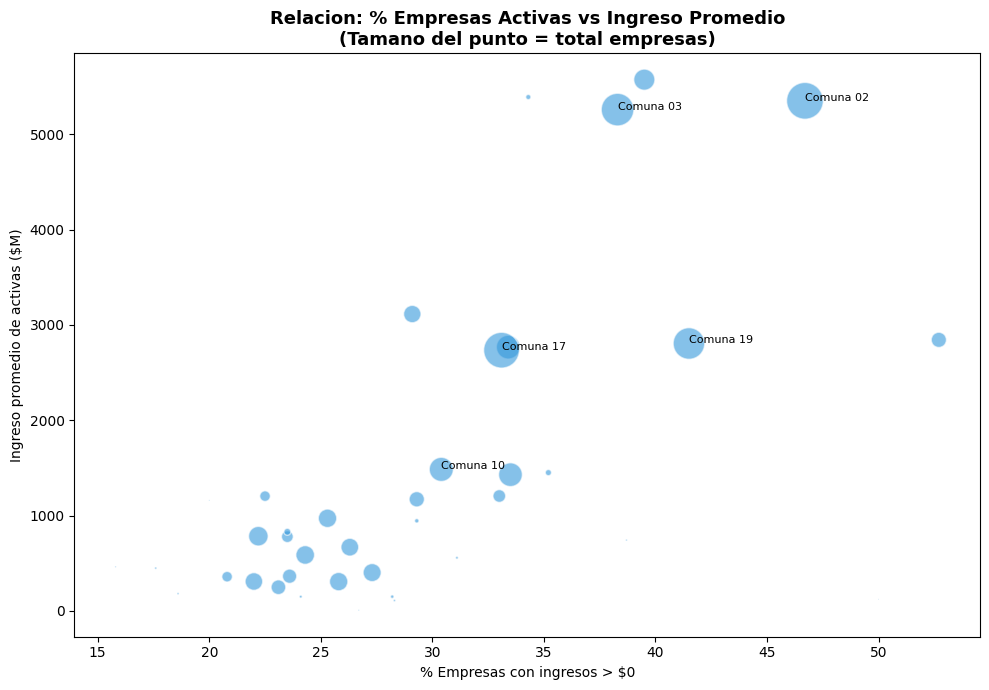

In [19]:
# 7.2 Ingresos promedio vs % empresas con ingresos (scatter)
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    ind['pct_con_ingresos'],
    ind['ingresos_prom_activas'] / 1e6,
    s=ind['total_empresas'] / 20,
    alpha=0.6,
    c='#3498db',
    edgecolors='white'
)
ax.set_xlabel('% Empresas con ingresos > $0')
ax.set_ylabel('Ingreso promedio de activas ($M)')
ax.set_title('Relacion: % Empresas Activas vs Ingreso Promedio\n(Tamano del punto = total empresas)', fontsize=13, fontweight='bold')

# Anotar las top 5
for _, r in ind_sorted.head(5).iterrows():
    if pd.notna(r.get('ingresos_prom_activas')) and pd.notna(r.get('pct_con_ingresos')):
        ax.annotate(r[col_comuna], (r['pct_con_ingresos'], r['ingresos_prom_activas']/1e6),
                   fontsize=8, ha='left')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ind_scatter_ingresos_activas.png', dpi=150, bbox_inches='tight', facecolor='white')
print('[OK] Guardado: ind_scatter_ingresos_activas.png')
plt.show()

[OK] Guardado: ind_comparativo_ingresos.png


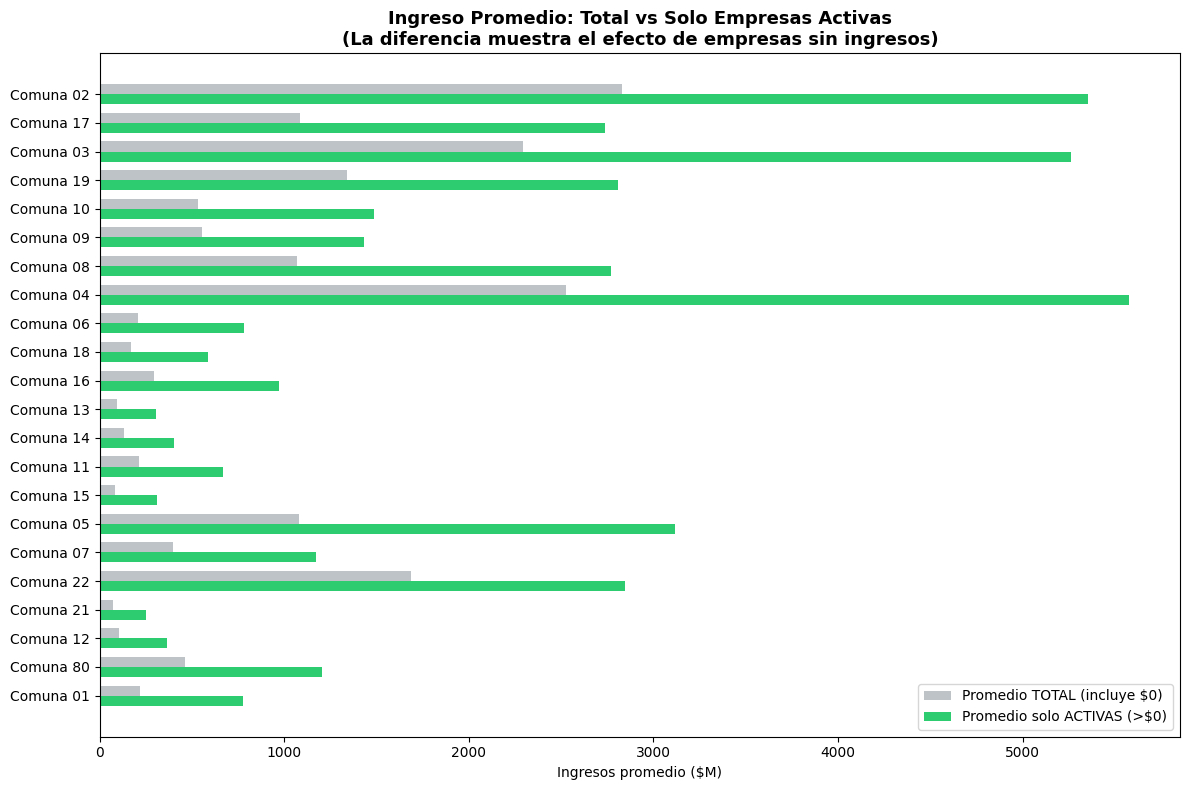

In [20]:
# 7.3 Comparativo: Ingreso promedio TOTAL vs solo ACTIVAS
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(top))
width = 0.35

bars1 = ax.barh(x - width/2, top['ingresos_promedio'].fillna(0) / 1e6, width, label='Promedio TOTAL (incluye $0)', color='#bdc3c7')
bars2 = ax.barh(x + width/2, top['ingresos_prom_activas'].fillna(0) / 1e6, width, label='Promedio solo ACTIVAS (>$0)', color='#2ecc71')

ax.set_yticks(x)
ax.set_yticklabels(top[col_comuna])
ax.set_xlabel('Ingresos promedio ($M)')
ax.set_title('Ingreso Promedio: Total vs Solo Empresas Activas\n(La diferencia muestra el efecto de empresas sin ingresos)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ind_comparativo_ingresos.png', dpi=150, bbox_inches='tight', facecolor='white')
print('[OK] Guardado: ind_comparativo_ingresos.png')
plt.show()

[OK] Guardado: ind_panel_cruzados_comuna.png


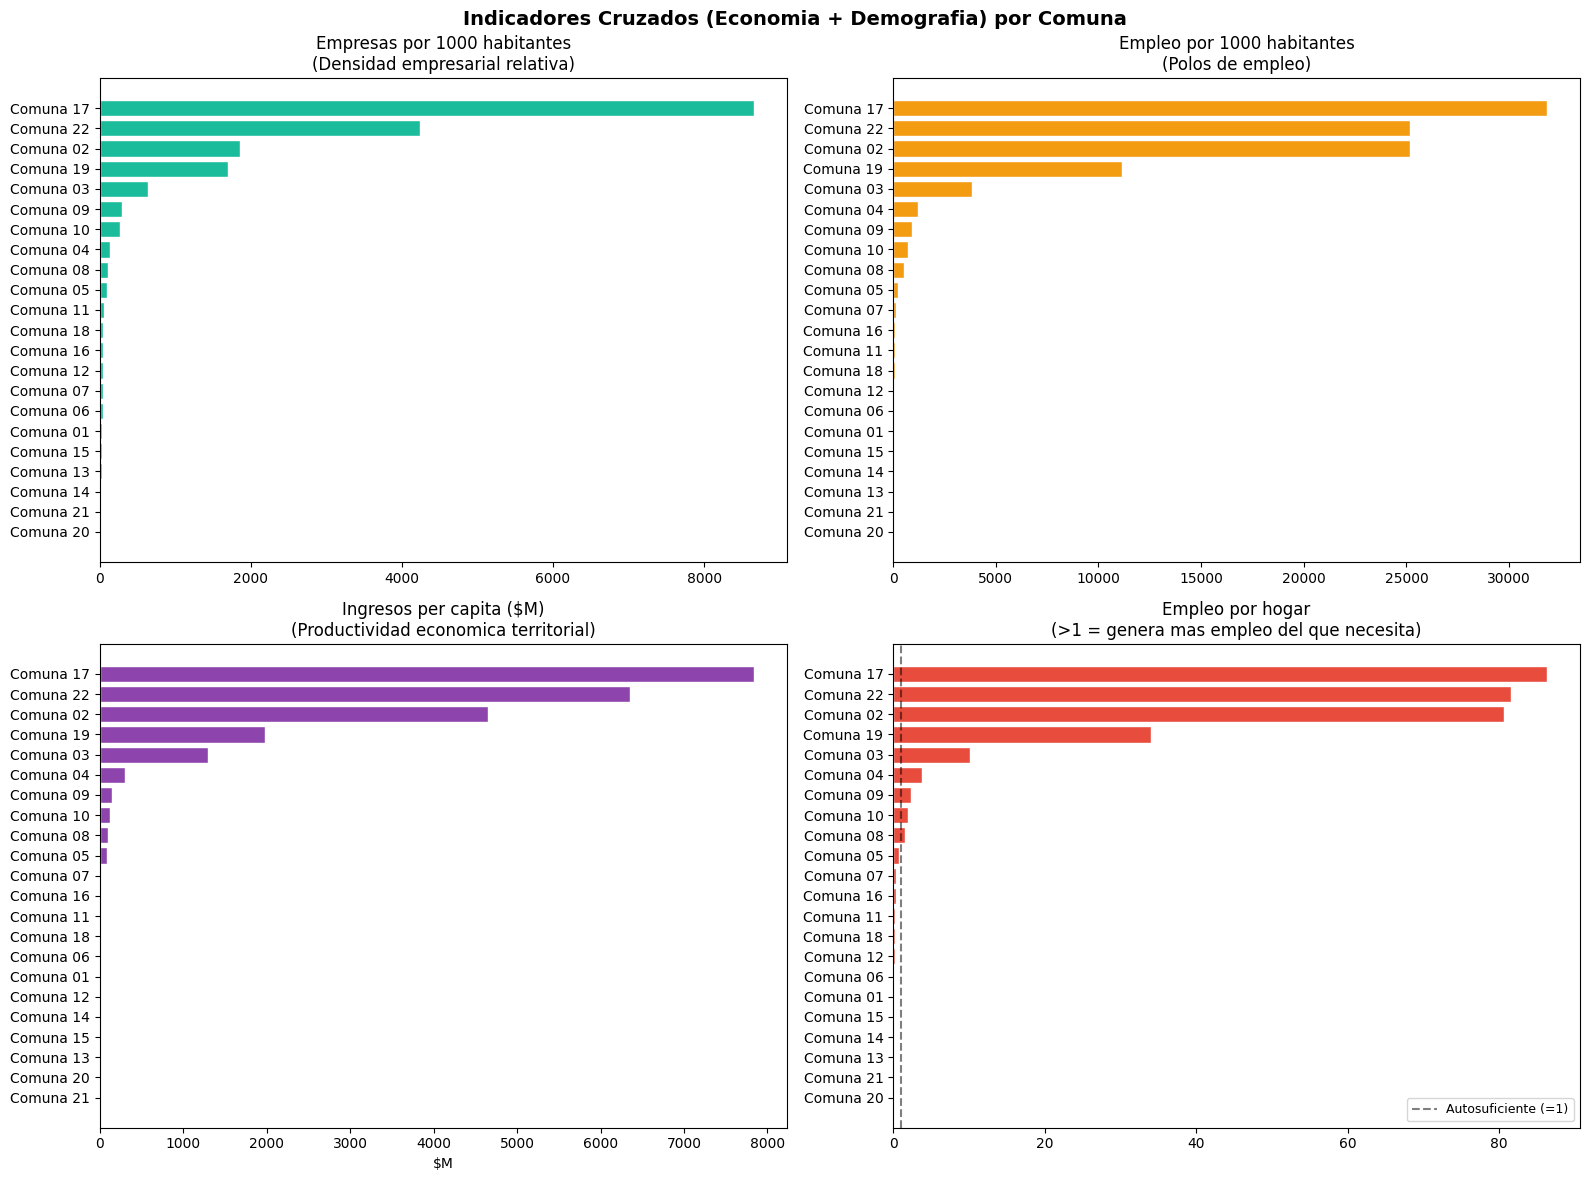

In [21]:
# 7.4 Si hay datos demograficos: indicadores cruzados
if has_demo:
    ind_demo = ind[ind['poblacion'].notna()].sort_values('empresas_por_1000hab', ascending=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Indicadores Cruzados (Economia + Demografia) por Comuna', fontsize=14, fontweight='bold')
    
    # Empresas/1000hab
    axes[0,0].barh(ind_demo[col_comuna], ind_demo['empresas_por_1000hab'], color='#1abc9c', edgecolor='white')
    axes[0,0].set_title('Empresas por 1000 habitantes\n(Densidad empresarial relativa)')
    axes[0,0].invert_yaxis()
    
    # Empleo/1000hab
    ind_demo2 = ind_demo.sort_values('empleo_por_1000hab', ascending=False)
    axes[0,1].barh(ind_demo2[col_comuna], ind_demo2['empleo_por_1000hab'], color='#f39c12', edgecolor='white')
    axes[0,1].set_title('Empleo por 1000 habitantes\n(Polos de empleo)')
    axes[0,1].invert_yaxis()
    
    # Ingresos per capita
    ind_demo3 = ind_demo.sort_values('ingresos_per_capita', ascending=False)
    axes[1,0].barh(ind_demo3[col_comuna], ind_demo3['ingresos_per_capita'].fillna(0) / 1e6, color='#8e44ad', edgecolor='white')
    axes[1,0].set_title('Ingresos per capita ($M)\n(Productividad economica territorial)')
    axes[1,0].set_xlabel('$M')
    axes[1,0].invert_yaxis()
    
    # Empleo/hogar
    ind_demo4 = ind_demo.sort_values('empleo_por_hogar', ascending=False)
    axes[1,1].barh(ind_demo4[col_comuna], ind_demo4['empleo_por_hogar'], color='#e74c3c', edgecolor='white')
    axes[1,1].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Autosuficiente (=1)')
    axes[1,1].set_title('Empleo por hogar\n(>1 = genera mas empleo del que necesita)')
    axes[1,1].legend(fontsize=9)
    axes[1,1].invert_yaxis()
    
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'ind_panel_cruzados_comuna.png', dpi=150, bbox_inches='tight', facecolor='white')
    print('[OK] Guardado: ind_panel_cruzados_comuna.png')
    plt.show()

## 8. Mapa coropletico - Ingresos per capita

[OK] Guardado: ind_mapas_ingresos_comuna.png


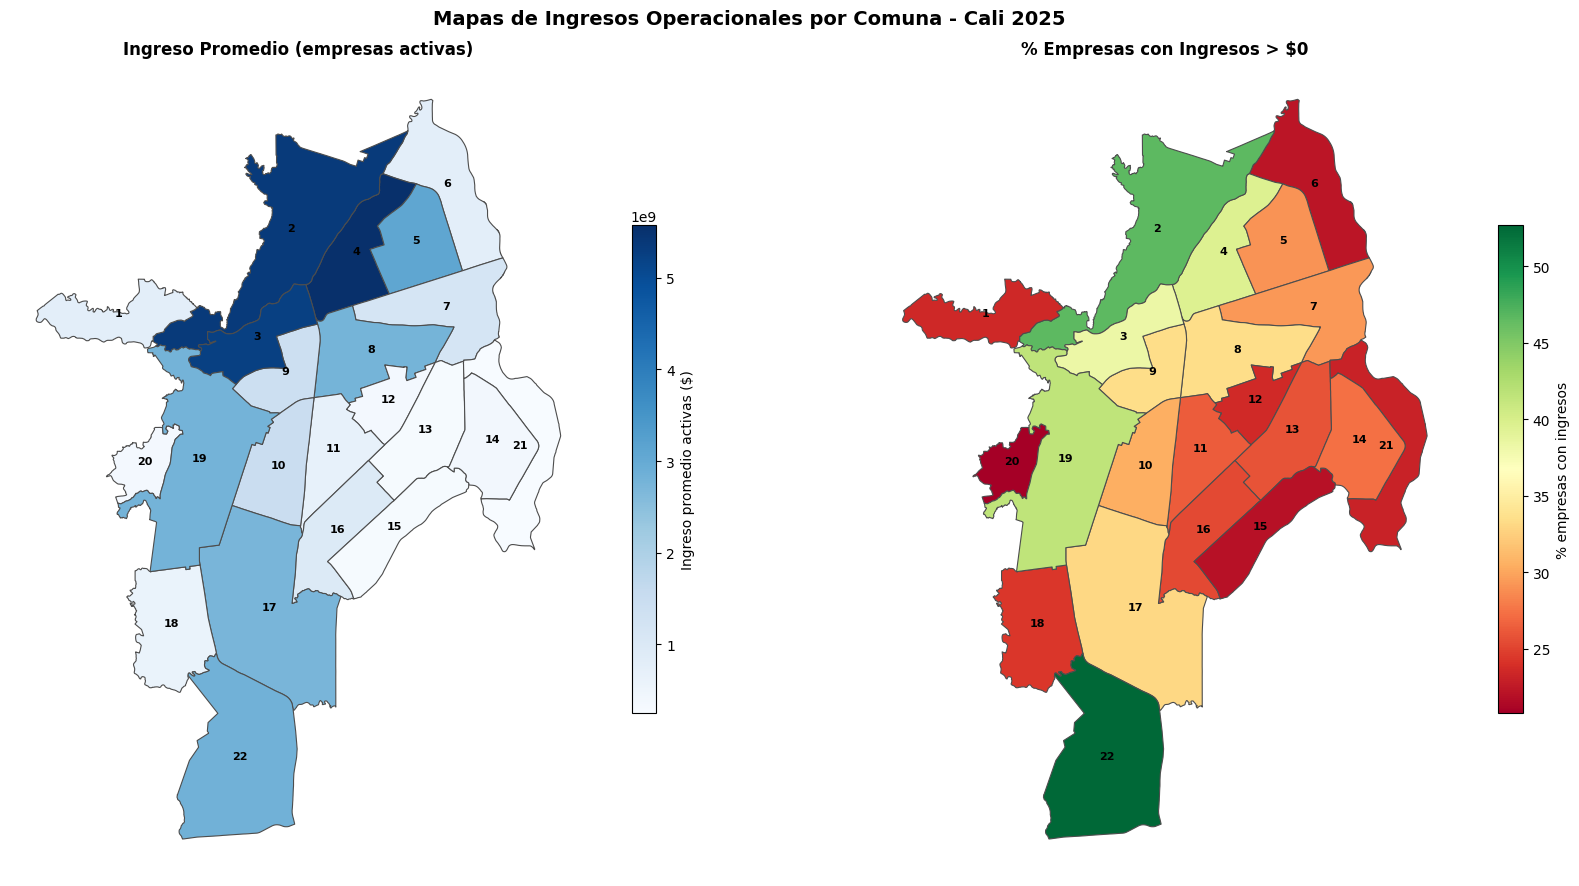

In [22]:
if gdf_comunas is not None:
    # Preparar merge con GeoJSON
    gdf_comunas['comuna_num'] = gdf_comunas['comuna'].astype(int)
    gdf_comunas['comuna_key'] = 'Comuna ' + gdf_comunas['comuna_num'].astype(str).str.zfill(2)
    
    gdf_map = gdf_comunas.merge(ind, left_on='comuna_key', right_on=col_comuna, how='left')
    
    # Mapa de ingresos promedio de activas
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    
    gdf_map.plot(column='ingresos_prom_activas', cmap='Blues', linewidth=0.8,
                 edgecolor='0.3', legend=True,
                 legend_kwds={'label': 'Ingreso promedio activas ($)', 'shrink': 0.6},
                 ax=axes[0], missing_kwds={'color': 'lightgrey'})
    for _, row in gdf_map.iterrows():
        c = row.geometry.centroid
        axes[0].annotate(str(int(row['comuna_num'])), xy=(c.x, c.y), ha='center', fontsize=8, fontweight='bold')
    axes[0].set_title('Ingreso Promedio (empresas activas)', fontsize=12, fontweight='bold')
    axes[0].set_axis_off()
    
    gdf_map.plot(column='pct_con_ingresos', cmap='RdYlGn', linewidth=0.8,
                 edgecolor='0.3', legend=True,
                 legend_kwds={'label': '% empresas con ingresos', 'shrink': 0.6},
                 ax=axes[1], missing_kwds={'color': 'lightgrey'})
    for _, row in gdf_map.iterrows():
        c = row.geometry.centroid
        axes[1].annotate(str(int(row['comuna_num'])), xy=(c.x, c.y), ha='center', fontsize=8, fontweight='bold')
    axes[1].set_title('% Empresas con Ingresos > $0', fontsize=12, fontweight='bold')
    axes[1].set_axis_off()
    
    plt.suptitle('Mapas de Ingresos Operacionales por Comuna - Cali 2025', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'ind_mapas_ingresos_comuna.png', dpi=150, bbox_inches='tight', facecolor='white')
    print('[OK] Guardado: ind_mapas_ingresos_comuna.png')
    plt.show()
else:
    print('[!] Sin GeoJSON para mapas.')

## 9. Reporte consolidado

In [24]:
from datetime import datetime

REPORTE = OUTPUT_DIR / 'indicadores_ingresos_comuna.txt'

with open(REPORTE, 'w', encoding='utf-8') as f:
    f.write('=' * 100 + '\n')
    f.write('INDICADORES DE INGRESOS OPERACIONALES POR COMUNA\n')
    f.write('Registro Mercantil 2025 - Santiago de Cali\n')
    f.write(f'Fecha: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write('=' * 100 + '\n\n')
    
    f.write('-' * 100 + '\n')
    f.write('INDICADORES CALCULADOS\n')
    f.write('-' * 100 + '\n')
    f.write('  1. total_empresas:        Conteo de matriculas por comuna\n')
    f.write('  2. ingresos_promedio:     Media de ingresos (incluye $0)\n')
    f.write('  3. ingresos_prom_activas: Media solo de empresas con ingresos > $0\n')
    f.write('  4. pct_con_ingresos:      % de empresas que reportan ingresos > $0\n')
    f.write('  5. empleo_total:          Suma de personal ocupado\n')
    f.write('  6. pct_micro:             % de microempresas\n')
    f.write('  7. n_ciiu:                Actividades economicas distintas\n')
    if has_demo:
        f.write('  8. empresas_por_1000hab:  Densidad empresarial relativa\n')
        f.write('  9. empleo_por_1000hab:    Capacidad de generacion de empleo\n')
        f.write(' 10. ingresos_per_capita:   Productividad economica territorial\n')
        f.write(' 11. empleo_por_hogar:      Autosuficiencia economica\n')
    f.write('\n')
    
    f.write('-' * 100 + '\n')
    f.write('TABLA DE INDICADORES\n')
    f.write('-' * 100 + '\n')
    f.write(ind_sorted.drop(columns=['comuna_key', 'n_micro', 'empresas_con_ingresos'], errors='ignore').to_string(index=False))
    f.write('\n\n')
    
    f.write('=' * 100 + '\n')
    f.write('FIN\n')
    f.write('=' * 100 + '\n')

print(f'[OK] Reporte guardado: {REPORTE.name}')

[OK] Reporte guardado: indicadores_ingresos_comuna.txt


## 10. Notas

**Indicadores mas relevantes para seguimiento temporal:**

1. **% Empresas con ingresos > $0** - El mas facil de medir y comparar entre periodos. Si sube, hay mas actividad real.
2. **Ingresos promedio de activas** - Excluye las que reportan $0, dando una imagen real del nivel economico.
3. **Empresas por 1000 hab** - Normalizado por poblacion, comparable entre comunas de cualquier tamano.
4. **Diversidad CIIU** - Mas actividades distintas = economia mas resiliente.
5. **Empleo por hogar** - Mide autosuficiencia economica del territorio.

**Formulas clave:**
- `ingresos_prom_activas = mean(ingresos) WHERE ingresos > 0` (excluye inactivas)
- `empresas_por_1000hab = (empresas / poblacion) * 1000` (normaliza por tamano)
- `empleo_por_hogar = empleo_total / hogares` (>1 = polo de empleo)